Analysis of the aggregated cell survival data
- With classic LQ fit
- With unweighted Rorvik

In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from sklearn.metrics import r2_score
from scipy.stats import t

In [2]:
BRITT_U2OS_DATA = False

SARA_A549_DATA = False

SARA_DU145_DATA = True

CHANGE THESE: the relevant folder and file paths

In [3]:
if BRITT_U2OS_DATA == True:
    Cell = 'U2OS'
    
    #enter list of paths to results folders here
    results_folders = []

    multi_x = []
    multi_p = [] #need to update all


In [4]:
if SARA_A549_DATA == True:
    Cell = 'A549'

    results_folders = [r'..\Cell data Sara A549\EXP_2025_10_16', r'..\Cell data Sara A549\EXP_2025_10_30', r'..\Cell data Sara A549\EXP_2025_11_18', r'..\Cell data Sara A549\EXP_2026_02_04']

    multi_x = [r'..\Cell data Sara A549\2025_10_16\Multiplicity X-rays 16-10.xlsx', r'..\Cell data Sara A549\2025_10_30\Multiplicity X-rays 30-10.xlsx', r'..\Cell data Sara A549\2025_11_18\Multiplicity X-rays 18-11.xlsx', r'..\Cell data Sara A549\2026_02_04\Multiplicity X-rays 4-2.xlsx']
    multi_p = [r'..\Cell data Sara A549\2025_10_16\Multiplicity protons 16-10.xlsx',r'..\Cell data Sara A549\2025_10_30\Multiplicity protons 30-10.xlsx', r'..\Cell data Sara A549\2025_11_18\Multiplicity protons 18-11.xlsx', r'..\Cell data Sara A549\2026_02_04\Multiplicity protons 4-2.xlsx']

In [5]:
if SARA_DU145_DATA == True:
    Cell = 'DU145'

    results_folders = [r'..\Cell data Sara DU145\EXP_2026_03_02', r'..\Cell data Sara DU145\EXP_2026_03_11', r'..\Cell data Sara DU145\EXP_2026_03_18', r'..\Cell data Sara DU145\EXP_2026_03_19']

    multi_x = [r'..\Cell data Sara DU145\2026_03_02\Multiplicity X-rays 2-3.xlsx', r'..\Cell data Sara DU145\2026_03_11\Multiplicity X-rays 11-3.xlsx', r'..\Cell data Sara DU145\2026_03_18\Multiplicity X-rays 18-3.xlsx', r'..\Cell data Sara DU145\2026_03_19\Multiplicity X-rays 19-3.xlsx']
    multi_p = [r'..\Cell data Sara DU145\2026_03_02\Multiplicity protons 2-3.xlsx', r'..\Cell data Sara DU145\2026_03_11\Multiplicity protons 11-3.xlsx', r'..\Cell data Sara DU145\2026_03_18\Multiplicity protons 18-3.xlsx', r'..\Cell data Sara DU145\2026_03_19\Multiplicity protons 19-3.xlsx']

Loading and importing data.

In [6]:
def write_fractions_dic(path):
    data = pd.read_excel(path)

    if BRITT_U2OS_DATA == True:
        total = np.array(data['Total'])[-1]

        fractions_dic = {}

        for column in data.items():
            if column[0] != 'Sample' and column[0] != 'Total': #ignore first and last column
                size = column[0]
                count = np.array(column[1])[-1]
                frac = count/total

                fractions_dic[size] = frac

    else:
        dic = data.to_dict(orient='records')
        fractions_dic = dic[0]

    print(fractions_dic)
    return fractions_dic

In [7]:
def cfu_survival_func(s, dic, SF):
    sum = 0
    for key, frac in dic.items():
        power = np.power((1-s),int(key))
        sum += frac*(1-power)
    
    #subtract the SF to use root
    sum -= SF
    return sum

In [8]:
def Parse_data(input, exp, fractions_dic):
    #Split colony counting data into cell survival for each sample
    #The survival is calculated for each triplicate separately and normalised to control
    #Also write LET to output for Rorvik calculations

    #inputs:
    #input = dataframe with the dose, plated cells and count of each triplicate for each sample, Format [Dose Plated Count1 Count2 Count3]

    #outputs:
    #output = dataframe with survival per triplicate and LET, Format [Dose LET Survival]

    def write_LET(rad_type):
        if rad_type == 'X':
            return 2.02
        if rad_type == 'Proton L':
            return 1.3
        if rad_type == 'Proton M':
            return 10.1
        if rad_type == 'Proton H':
            return 16.5

    def set_color(exp):
        if exp == 'EXP_2025_10_16':
            return '#00FFFF'
        if exp == 'EXP_2025_10_30':
            return '#0000FF'
        if exp == 'EXP_2025_11_18':
            return '#00008B'
        if (exp == 'EXP_2026_2_04') or (exp == 'EXP_2026_02_04'):
            return '#4B0082'
        if exp == 'EXP_2026_2_26':
            return '#008080'
        if (exp == 'EXP_2026_03_02') or (exp == 'EXP_2026_3_02'):
            return '#FF00FF'
        if (exp == 'EXP_2026_3_11') or (exp == 'EXP_2026_03_11'):
            return '#9ACD32' 
        if (exp == 'EXP_2026_3_18') or (exp == 'EXP_2026_03_18'):
            return '#008000'
        if (exp == 'EXP_2026_3_19') or (exp == 'EXP_2026_03_19'):
            return '#00FF00'

    triplicates_control = ["Count_1", "Count_2", "Count_3","Count_4", "Count_5", "Count_6"]

    #Isolate controls, calculate control survival for normalising
    control_data = input[input['Dose'] == 0]
    control_survival = control_data[triplicates_control].mean(axis=1)/control_data['Plated']

    #Write data to output with dose and survival
    output = pd.DataFrame(columns=['Dose', 'LET', 'Survival'])

    #Loop through rows of input to process data and write to output.
    #Each triplicate is processed separately
    for row in input.itertuples():
        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_1/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        newrow['c'] = set_color(exp)
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_2/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        newrow['c'] = set_color(exp)
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_3/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        newrow['c'] = set_color(exp)
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        if row.Dose == 0:
            newrow = {}
            newrow['Dose'] = row.Dose
            survival = (row.Count_4/row.Plated)/control_survival
            newrow['SF'] = float(survival.iloc[0])
            newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
            newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
            newrow['Experiment'] = exp
            newrow['c'] = set_color(exp)
            output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

            newrow = {}
            newrow['Dose'] = row.Dose
            survival = (row.Count_5/row.Plated)/control_survival
            newrow['SF'] = float(survival.iloc[0])
            newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
            newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
            newrow['Experiment'] = exp
            newrow['c'] = set_color(exp)
            output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

            newrow = {}
            newrow['Dose'] = row.Dose
            survival = (row.Count_6/row.Plated)/control_survival
            newrow['SF'] = float(survival.iloc[0])
            newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
            newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
            newrow['Experiment'] = exp
            newrow['c'] = set_color(exp)
            output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

    return output

In [9]:
#Load and process data

#Loop through folders to extract all excels and write to dataframes
X = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment', 'c'])
PL = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment', 'c'])
PM = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment', 'c'])
PH = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment', 'c'])

for i in range(len(results_folders)):
    folder = results_folders[i]
    experi = os.path.split(folder)[-1]
    multiplicity_x = write_fractions_dic(multi_x[i])
    multiplicity_p = write_fractions_dic(multi_p[i])
    for file in os.listdir(folder):
        if os.path.splitext(os.path.join(folder, file))[-1] == '.xlsx':
            #Read in if it's an excel file
            df = pd.read_excel(os.path.join(folder, file), index_col=None)

            #Check the radiation type and write to correct dataframe
            if df.tail(1)['Rad'].item() == 'X':
                data = Parse_data(df, experi, multiplicity_x)
                #Correct X-ray dose
                data['Dose'] = 0.85*data['Dose'] 
                X = pd.concat([X, data])   
            if df.tail(1)['Rad'].item() == 'Proton L':
                data = Parse_data(df, experi, multiplicity_p)
                data['Dose'] = data['Dose']
                PL = pd.concat([PL, data])
            if df.tail(1)['Rad'].item() == 'Proton H':
                data = Parse_data(df, experi, multiplicity_p)
                data['Dose'] = data['Dose']
                PH = pd.concat([PH, data])
            if df.tail(1)['Rad'].item() == 'Proton M':
                data = Parse_data(df, experi, multiplicity_p)
                data['Dose'] = data['Dose']
                PM = pd.concat([PM, data])



{1: 0.948328267, 2: 0.051671733, 3: 0, 4: 0}
{1: 0.95951417, 2: 0.036437247, 3: 0.004048583, 4: 0}
{1: 0.92721519, 2: 0.060126582, 3: 0.009493671, 4: 0.003164557}
{1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}


C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\2811872922.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\3474228667.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  PH = pd.concat([PH, data])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\2811872922.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a f

{1: 0.902439024, 2: 0.094076655, 3: 0.003484321, 4: 0}
{1: 0.925696594, 2: 0.068111455, 3: 0.00619195, 4: 0}


C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\2811872922.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\2811872922.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\2811872922.py:62: FutureWarning: The behavior of DataFrame concatenation with 

{1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}
{1: 0.931034483, 2: 0.068965517, 3: 0, 4: 0}


# Rørvik fit

In [10]:
def R_Func(X, a, b, c):
    d, l, dtwo = X
    return np.exp(-(a*d + b*l + c*dtwo))

In [11]:
def Rorvik_fit_scipy(sample):
    #inputs:
    #sample = dataframe as ['Dose' 'Mean Survival'] for all triplicates, as outputted by 'Process_data'

    #returns:
    #params = np array containing the two LQ fit parameters
    #lower and upper bounds for the confidence interval

    def Function(X, a, b, c):
        d, l, dtwo = X
        return np.exp(-(a*d + b*l + c*dtwo))

    dose = np.array(sample['Dose'], dtype='float')
    let = np.array(sample['LET'], dtype = 'float')
    X= np.array((dose, dose*let, np.square(dose)))

    y = np.array(sample['Survival'], dtype = 'float')

    p0 = (0.1, 0.1, 0.1)

    popt, pcov = curve_fit(Function, X, y, p0=p0, bounds=(0,1))

    #calculate confidence interval
    def bootstrap_fit(ddata, ldata, ydata, n_boot):
        n = len(ddata)
        params = np.zeros([n_boot, 3])

        for b in range(n_boot):
            # resample indices with replacement
            idx = np.random.randint(0, n, n)

            d_resampled = ddata[idx]
            l_resampled = ldata[idx]
            X_resampled = X= np.array((d_resampled, d_resampled*l_resampled, np.square(d_resampled)))
            y_resampled = ydata[idx]

            try:
                popt, pcov = curve_fit(Function, X_resampled, y_resampled, (0.1, 0.1, 0.1), bounds=(0,1))
                params[b,:] = popt
            except RuntimeError:
                # skip failed fits
                continue

        return params
    
    boot_params = bootstrap_fit(dose, let, y, 2000)

    alpha_samples = boot_params[:, 0]
    k_samples  = boot_params[:, 1]
    beta_samples  = boot_params[:, 2]

    #Get 2 sigma confidence interval
    alpha_ci = np.percentile(alpha_samples, [2.5, 97.5])
    k_ci = np.percentile(k_samples, [2.5, 97.5])
    beta_ci  = np.percentile(beta_samples,  [2.5, 97.5])

    alpha_mean = np.mean(alpha_samples)
    k_mean = np.mean(k_samples)
    beta_mean  = np.mean(beta_samples)
    
    return [alpha_mean, k_mean, beta_mean], [alpha_ci[0], k_ci[0], beta_ci[0]], [alpha_ci[1], k_ci[1], beta_ci[1]]

In [12]:
#Take copies
X_rorvik = X.copy()
PL_rorvik = PL.copy()
PH_rorvik = PH.copy()

#Remove any zero survivals
X_rorvik = X_rorvik[X_rorvik['SF']!=0]
PL_rorvik = PL_rorvik[PL_rorvik['SF']!=0]
PH_rorvik = PH_rorvik[PH_rorvik['SF']!=0]

#Remove 8 Gy
#PL_rorvik = PL_rorvik[PL_rorvik['Dose']!=8]
if BRITT_U2OS_DATA == True:
    PH_rorvik = PH_rorvik[PH_rorvik['Dose']!=8]

#Remove NaN
X_rorvik.dropna(inplace=True, subset=['SF'])
PL_rorvik.dropna(inplace=True, subset=['SF'])
PH_rorvik.dropna(inplace=True, subset=['SF'])

C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\189536338.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  X_curated = pd.concat([X_curated, curated_data])


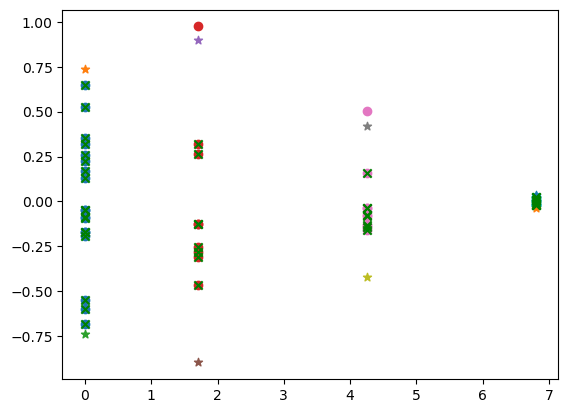

In [13]:
#Plot residuals of X data
X_curated = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment', 'c'])
for dose in np.unique(X_rorvik['Dose']):
    data = X_rorvik[X_rorvik['Dose']==dose]
    Res = data['Survival'] - data['Survival'].mean()
    sigma = data['Survival'].std()

    plt.scatter(data['Dose'],Res)
    plt.scatter(dose, 2*sigma, marker='*')
    plt.scatter(dose, -2*sigma, marker='*')

    #Curate data
    # For each dose, do away with anything < lower boundary or > upper boundary
    lower_boundary = data['Survival'].mean() - 2*sigma
    upper_boundary = data['Survival'].mean() + 2*sigma
    curated_data = data[(data['Survival'] > lower_boundary)&(data['Survival'] < upper_boundary)]

    # Re-plot the residuals to mark the points that stay
    Res_new = curated_data['Survival']-data['Survival'].mean()
    plt.scatter(curated_data['Dose'], Res_new, marker='x', color='green')

    # Concatenate to curated dataframe
    X_curated = pd.concat([X_curated, curated_data])

C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\4198848804.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  PL_curated = pd.concat([PL_curated, curated_data])


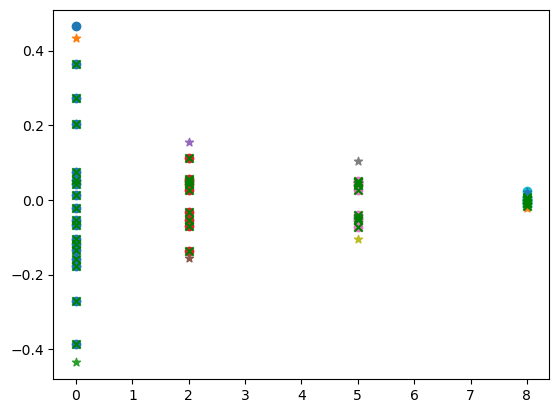

In [14]:
#Plot residuals of PL data
PL_curated = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment', 'c'])
for dose in np.unique(PL_rorvik['Dose']):
    data = PL_rorvik[PL_rorvik['Dose']==dose]
    Res = data['Survival'] - data['Survival'].mean()
    sigma = data['Survival'].std()

    plt.scatter(data['Dose'],Res)
    plt.scatter(dose, 2*sigma, marker='*')
    plt.scatter(dose, -2*sigma, marker='*')

    #Curate data
    # For each dose, do away with anything < lower boundary or > upper boundary
    lower_boundary = data['Survival'].mean() - 2*sigma
    upper_boundary = data['Survival'].mean() + 2*sigma
    curated_data = data[(data['Survival'] > lower_boundary)&(data['Survival'] < upper_boundary)]

    # Re-plot the residuals to mark the points that stay
    Res_new = curated_data['Survival']-data['Survival'].mean()
    plt.scatter(curated_data['Dose'], Res_new, marker='x', color='green')
    
    # Concatenate to curated dataframe
    PL_curated = pd.concat([PL_curated, curated_data])

C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\3578252062.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  PH_curated = pd.concat([PH_curated, curated_data])


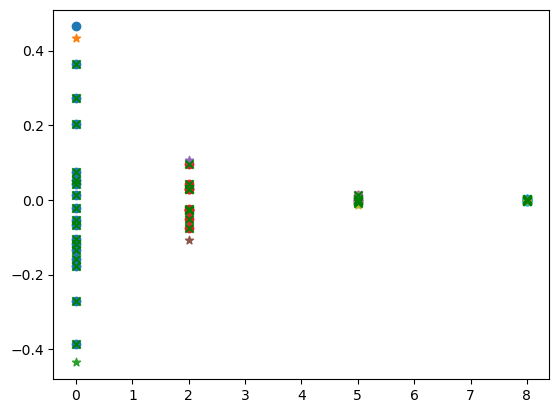

In [15]:
#Plot residuals of PH data
PH_curated = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment', 'c'])
for dose in np.unique(PH_rorvik['Dose']):
    data = PH_rorvik[PH_rorvik['Dose']==dose]
    Res = data['Survival'] - data['Survival'].mean()
    sigma = data['Survival'].std()

    plt.scatter(data['Dose'],Res)
    plt.scatter(dose, 2*sigma, marker='*')
    plt.scatter(dose, -2*sigma, marker='*')

    #Curate data
    # For each dose, do away with anything < lower boundary or > upper boundary
    lower_boundary = data['Survival'].mean() - 2*sigma
    upper_boundary = data['Survival'].mean() + 2*sigma
    curated_data = data[(data['Survival'] > lower_boundary)&(data['Survival'] < upper_boundary)]

    # Re-plot the residuals to mark the points that stay
    Res_new = curated_data['Survival']-data['Survival'].mean()
    plt.scatter(curated_data['Dose'], Res_new, marker='x', color='green')
    
    # Concatenate to curated dataframe
    PH_curated = pd.concat([PH_curated, curated_data])

In [16]:
#Aggregate data back into one dataframe
total_data = pd.concat([X_curated, PL_curated, PH_curated])

#Fit curve scipy
params, low, up = Rorvik_fit_scipy(total_data)
params_rorvik = params

print('a: ' + str(round(params[0],3)) + f' \u00B1 {round((up[0]-low[0])/2,3)}')
print('k: ' + str(round(params[1],3)) + f' \u00B1 {round((up[1]-low[1])/2,3)}')
print('b: ' + str(round(params[2],3)) + f' \u00B1 {round((up[2]-low[2])/2,3)}')

#calculate alpha0
d0 = 0
d1 = 0.1

x0 = (d0, d0*2.02, np.square(d0))
x1 = (d1, d1*2.02, np.square(d1))

s0 = R_Func(x0, params[0], params[1], params[2])
s1 = R_Func(x1, params[0], params[1], params[2])

a0 = -((s1-s0)/(d1-d0))
print('a0: ' + str(a0))

abpm = np.sqrt((((up[0]-low[0])/2)/params[0]) + (((up[2]-low[2])/2)/params[2]))
print('a/b: ' + str(round(params[0]/params[2],2)) + f' \u00B1 {round(abpm,2)}')

# d = np.linspace(0,8,100)
# #Plot to confirm
# let = X_rorvik.iloc[0]['LET']
# x = (d, d*let, np.square(d))
# y_x = R_Func(x, params[0], params[1], params[2])
# plt.errorbar(X_rorvik['Dose'], X_rorvik['Survival'], xerr=0.071*X_rorvik['Dose'], label='225 kV X-rays', color='blue', fmt='+', capsize=3)
# plt.plot(d, y_x, color='blue')
# plt.plot(d, np.exp(-a0*d))
# plt.yscale('log')

a: 0.407 ± 0.141
k: 0.024 ± 0.008
b: 0.006 ± 0.018
a0: 0.4450054064267073
a/b: 70.38 ± 1.86


In [17]:
def Process_data(input):
    #Process [Dose Survival] data per sample into a mean and std per triplicate

    #inputs
    #df = dataframe [Dose Survival Experiment] per sample as outputted by the cell loading the data

    #output
    #df_means = dataframe ['Dose' 'Mean Survival' 'Experiment] per triplicate
    #df_stds = standard deviation of log of survival per triplicate

    #copy the input for processing
    df = input.copy()
    dose_levels = np.unique(df['Dose'])

    df_means_total = pd.DataFrame(columns=['Dose', 'Mean Survival', 'STD', 'Experiment', 'c'])

    for exp in np.unique(df['Experiment']):
        data = df[df['Experiment']==exp]
        color = data['c']

        #Process into mean and std per triplicate
        df_means = pd.DataFrame(columns=['Dose', 'Mean Survival', 'STD', 'Experiment', 'c'])

        for i in range(len(dose_levels)):
            dose = dose_levels[i]
            
            #Select triplicate
            trip = data[data['Dose']==dose]
            newrow = {}

            #Write dose
            newrow['Dose'] = dose
            newrow['Experiment'] = trip['Experiment'].iloc[0]
            newrow['c'] = color

            #Calculate mean, ignoring any NaN values
            newrow['Mean Survival'] = np.nanmean(np.array(trip['Survival']))
            #Write standard dev
            newrow['STD'] = np.nanstd(np.array(trip['Survival']))/np.sqrt(3)
            df_means = pd.concat([df_means, pd.DataFrame([newrow])])


        #Re-normalise with multiplicities
        df_means['Mean Survival'] = df_means['Mean Survival']/df_means['Mean Survival'].iloc[0] 

        df_means_total = pd.concat([df_means_total, df_means])   

    return df_means_total 

In [18]:
#Save data for MONAS input
total_data.to_excel(f'..\\Total data {Cell}.xlsx')
PL_means = Process_data(PL_curated)
PL_means.to_excel(f'..\\PL_means {Cell}.xlsx')
PH_means = Process_data(PH_curated)
PL_means.to_excel(f'..\\PH_means {Cell}.xlsx')

C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\2983639260.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means = pd.concat([df_means, pd.DataFrame([newrow])])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\2983639260.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means_total = pd.concat([df_means_total, df_means])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\2983639260.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is depre

In [19]:
X_rorvik = X_curated
PL_rorvik = PL_curated
PH_rorvik = PH_curated

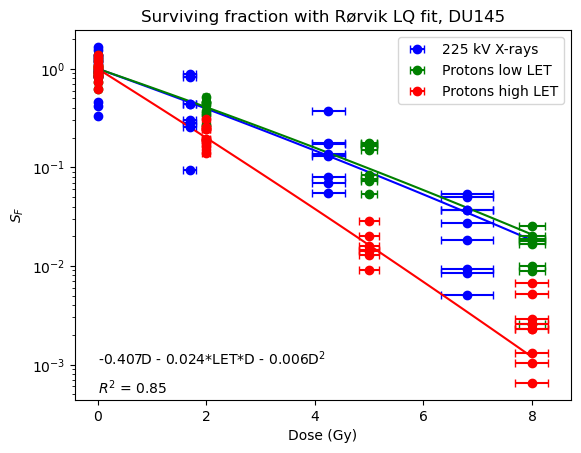

In [20]:
#Plot data
d = np.linspace(0,8,100)

let = X_rorvik.iloc[0]['LET']
x = (d, d*let, np.square(d))
y_x = R_Func(x, params[0], params[1], params[2])
plt.errorbar(X_rorvik['Dose'], X_rorvik['Survival'], xerr=0.071*X_rorvik['Dose'], label='225 kV X-rays', color='blue', fmt='o', capsize=3)
plt.plot(d, y_x, color='blue')

let = PL_rorvik.iloc[0]['LET']
x = (d, d*let, np.square(d))
y_pl = R_Func(x, params[0], params[1], params[2])
plt.errorbar(PL_rorvik['Dose'], PL_rorvik['Survival'], xerr=0.029*PL_rorvik['Dose'], label='Protons low LET', fmt='o', color='g', capsize=3)
plt.plot(d, y_pl, color='g')

let = PH_rorvik.iloc[0]['LET']
x = (d, d*let, np.square(d))
y_ph = R_Func(x, params[0], params[1], params[2])
plt.errorbar(PH_rorvik['Dose'], PH_rorvik['Survival'], xerr=0.038*PH_rorvik['Dose'], label='Protons high LET', fmt='o', color='r', capsize=3)
plt.plot(d, y_ph, color='r')

#Customise
plt.xlabel('Dose (Gy)')
plt.ylabel('$S_F$')
plt.title(f'Surviving fraction with Rørvik LQ fit, {Cell}')
plt.legend()
plt.yscale('log')
plt.text(0, 1e-3, f"-{round(params[0],3)}D - {round(params[1],3)}*LET*D - {round(params[2],3)}D$^2$")

#R2
BigX = [total_data['Dose'].astype(float), total_data['LET'].astype(float)*total_data['Dose'].astype(float), np.square(total_data['Dose'].astype(float))]
pred = R_Func(BigX, params[0],params[1],params[2])
r2rorvik = r2_score(total_data['Survival'].astype(float), pred)
plt.text(0, 5e-4, f"$R^2$ = {round(r2rorvik, 2)}")
plt.savefig(r"C:\Users\bhaan\Downloads\Rorvik survival fit 300 dpi.png", dpi=300, bbox_inches='tight')

Attempt to implement RBE model according to Rorvik

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\180522021.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('LET (keV/$\mu$m)')


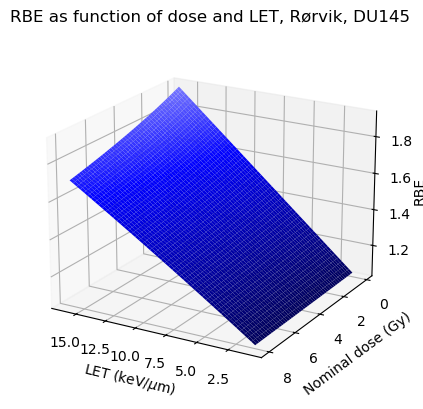

In [21]:
letvals = np.linspace(1, 16, 1000)
dosevals = np.linspace(0.1, 8, 1000)
letvals, dosevals = np.meshgrid(letvals, dosevals)

a_x = params[0]
b_x = params[2]
k = params[1]

RBEmin = 1
RBEmax = 1 + (k/a_x)*letvals
A_B = a_x/b_x

squareterm = np.square(A_B) + 4*dosevals*A_B*RBEmax + 4*np.square(dosevals)*np.square(RBEmin)
RBE = (1/(2*dosevals))*(np.sqrt(squareterm) - A_B)

fig = plt.figure()

ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax1.view_init(elev=20, azim=120, roll=0)
ax1.plot_surface(letvals, dosevals, RBE, cmap = 'seismic', vmin=1, vmax=3.5)
ax1.set_xlabel('LET (keV/$\mu$m)')
ax1.set_ylabel('Nominal dose (Gy)')
ax1.set_zlabel('RBE', rotation=90)
ax1.zaxis.labelpad=-0.8 
ax1.set_title(f'RBE as function of dose and LET, Rørvik, {Cell}')
plt.savefig(r"C:\Users\bhaan\Downloads\Rorvik RBE 3D 300 dpi.png", dpi=300, bbox_inches='tight')

In [22]:
print('Max RBE: ' + str(round(np.max(RBE),1)))
print('Min RBE: ' + str(round(np.min(RBE),1)))

Max RBE: 1.9
Min RBE: 1.0


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_20220\2742880828.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('LET (keV/$\mu$m)')


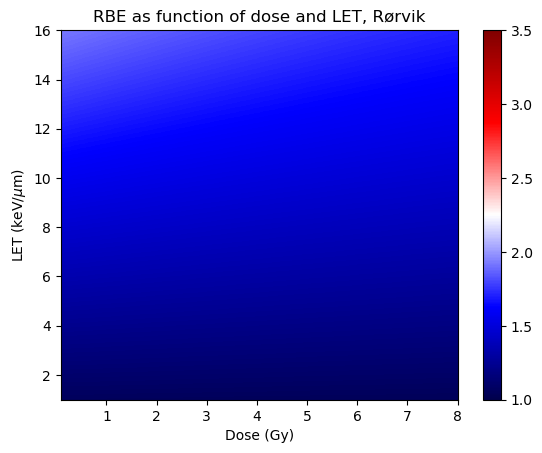

In [23]:
plt.pcolormesh(dosevals, letvals, RBE, cmap='seismic', vmin=1, vmax=3.5)
plt.ylabel('LET (keV/$\mu$m)')
plt.xlabel('Dose (Gy)')
plt.title('RBE as function of dose and LET, Rørvik')
plt.colorbar()

# Bootstrap uncertainty analysis for RBE fit

In [24]:
def Rorvik_fit_single(sample):
    #inputs:
    #sample = dataframe as ['Dose' 'Mean Survival'] for all triplicates, as outputted by 'Process_data'

    #returns:
    #params = np array containing the two LQ fit parameters
    #lower and upper bounds for the confidence interval

    def Function(X, a, b, c):
        d, l, dtwo = X
        return np.exp(-(a*d + b*l + c*dtwo))

    dose = np.array(sample['Dose'], dtype='float')
    let = np.array(sample['LET'], dtype = 'float')
    X= np.array((dose, dose*let, np.square(dose)))

    y = np.array(sample['Survival'], dtype = 'float')

    p0 = (0.1, 0.1, 0.1)

    popt, pcov = curve_fit(Function, X, y, p0=p0, bounds=(0,1))

    return popt

In [25]:
def Calculate_RBE(d, let, p):

    if d == 0:
        RBE[i] = 1

    else:
        a_x = p[0]
        b_x = p[2]
        k = p[1]

        RBEmin = 1
        RBEmax = 1 + (k/a_x)*let
        A_B = a_x/b_x

        squareterm = np.square(A_B) + 4*d*A_B*RBEmax + 4*np.square(d)*np.square(RBEmin)
        RBE = (1/(2*d))*(np.sqrt(squareterm) - A_B)

    return RBE

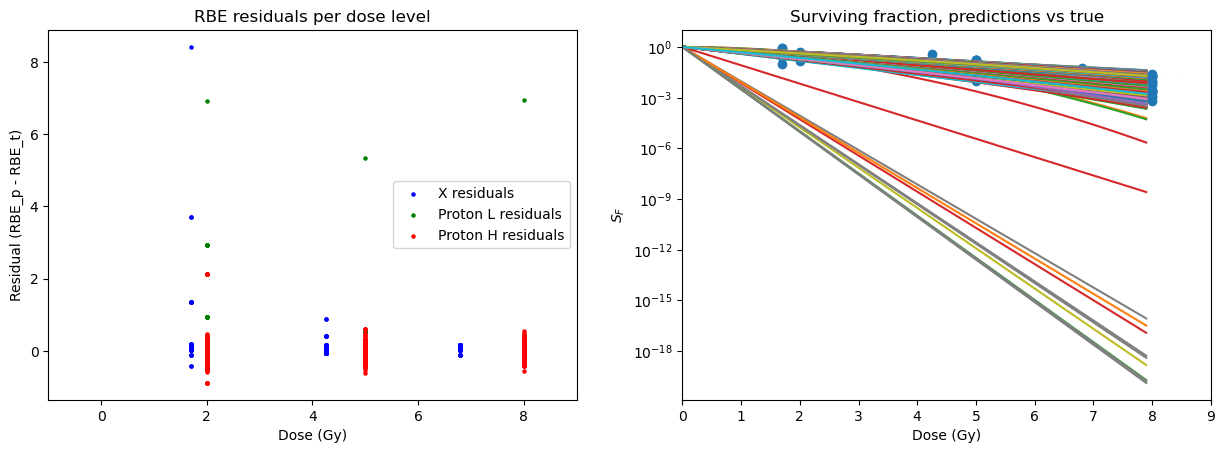

In [26]:
total_data = total_data[total_data['Dose'] != 0]
#Sample size
n_sample = len(total_data)
#number of bootstrap samples
n_bootstraps = 1000

Residuals_x = np.array([])
Residuals_pl = np.array([])
Residuals_ph = np.array([])
Bootstrap_doses_x = np.array([])
Bootstrap_doses_pl = np.array([])
Bootstrap_doses_ph = np.array([])

#prepare figures
figure, axis = plt.subplots(1,2)
axis[1].scatter(total_data['Dose'], total_data['Survival'], label="True")
figure.set_figwidth(15)

bs = 0
while bs < n_bootstraps:
    #Resample the data into a bootstrap sample (so with replacement)
    indices = np.random.randint(0, n_sample, n_sample) #randomly generate indexes
    
    #resample data
    Doses_b = total_data['Dose'].iloc[indices]
    let_b = total_data['LET'].iloc[indices]
    survival_b = total_data['Survival'].iloc[indices]

    #refit parameters
    total_b = pd.concat([Doses_b, let_b, survival_b], axis=1)
    total_b.sort_values(by='Dose', inplace=True, ascending=True)
    params = Rorvik_fit_single(total_b)

    #calculate resulting RBE and residual for each dose/let combo
    let_vals = np.unique(let_b)
    for let in let_vals:
        dos = total_data[total_data['LET'] == let]
        dose_vals = np.unique(dos['Dose'])
        for dose in dose_vals:
            rbe = Calculate_RBE(dose, let, params)
            if (rbe>10) or (rbe <= 0):
                break

            #Calculate residual
            if let == 2.02:
                residual = rbe - 1
                Residuals_x = np.append(Residuals_x, np.array(residual))
                Bootstrap_doses_x = np.append(Bootstrap_doses_x, np.array(dose))
            if let == 1.30:
                residual = rbe - Calculate_RBE(dose, let, params_rorvik)
                Residuals_pl = np.append(Residuals_pl, np.array(residual))
                Bootstrap_doses_pl = np.append(Bootstrap_doses_pl, np.array(dose))
            if let == 16.5:
                residual = rbe - Calculate_RBE(dose, let, params_rorvik)
                Residuals_ph = np.append(Residuals_ph, np.array(residual))
                Bootstrap_doses_ph = np.append(Bootstrap_doses_ph, np.array(dose))

            #print('RBE: ' + str(rbe) + ' Residual: ' + str(residual) + ', LET: ' + str(let), ', Dose: ' + str(dose))

    #Plot prediction vs data for each dose level
    for let in let_vals:
        d = np.arange(0, 8, 0.1)
        dat = (d, let*d, np.square(d))
        axis[1].plot(d, R_Func(np.array(dat).astype(float), params[0], params[1], params[2]), label=str(bs))

    bs += 1
    
#Plot residuals for each dose level
axis[0].scatter(Bootstrap_doses_x, Residuals_x, s=5, label='X residuals', c='b')
axis[0].scatter(Bootstrap_doses_pl, Residuals_pl, s=5, label='Proton L residuals', c='g')
axis[0].scatter(Bootstrap_doses_ph, Residuals_ph, s=5, label='Proton H residuals', c='r')

#Customise residual plot
axis[0].set_xlabel("Dose (Gy)")
axis[0].set_ylabel("Residual (RBE_p - RBE_t)")
axis[0].set_title("RBE residuals per dose level")
axis[0].set_xlim([-1, 9])
axis[0].legend()
# axis[0].legend(loc="center right")

#Customise prediction plot
axis[1].set_xlabel("Dose (Gy)")
axis[1].set_ylabel('$S_F$')
axis[1].set_title("Surviving fraction, predictions vs true")
axis[1].set_xlim([0, 9])
axis[1].set_yscale('log')
# axis[1].legend(loc="center right")


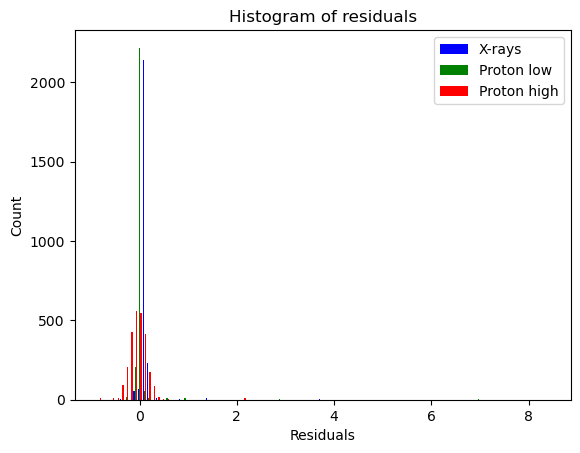

In [27]:
#Make residuals data into a 1D array, sorted smallest to largest
for Res in (Residuals_x, Residuals_pl, Residuals_ph):
    Res = Res.reshape(-1)
    index = np.argsort(Res)
    Res = np.array([Res[i] for i in index])

plt.title("Histogram of residuals")
plt.hist([Residuals_x, Residuals_pl, Residuals_ph], bins=100, label=['X-rays', 'Proton low', 'Proton high'], color=['b', 'g', 'r'])
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.legend()

In [28]:
#Iteratively loop through uncertainty values until 95% of residual data lies within these values
Res = np.concatenate([Residuals_x, Residuals_pl, Residuals_ph])
Res = Res.reshape(-1)
index = np.argsort(Res)
Res = np.array([Res[i] for i in index])

#Find 95 percentile
Res_ci = np.percentile(Res, [2.5, 97.5])
Res_mean = np.mean(Res)

pmvalue = Res_ci[1] - Res_mean
print("Uncertainty value: \u00B1" + str(round(pmvalue,2)))
print("Percentage of data within these bounds: 95%")

Uncertainty value: ±0.19
Percentage of data within these bounds: 95%


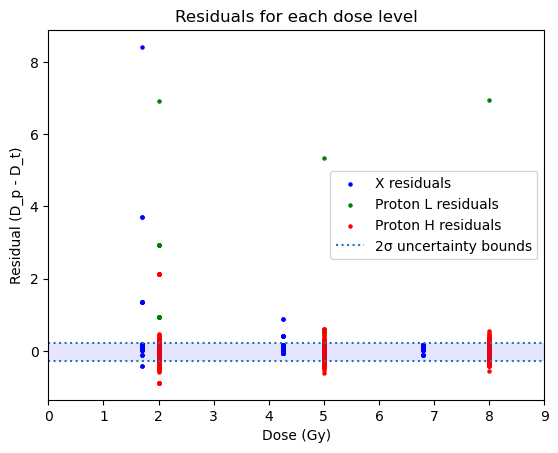

In [29]:
#Replot residuals with uncertainty bounds
plt.scatter(Bootstrap_doses_x, Residuals_x, s=5, label='X residuals', c='b')
plt.scatter(Bootstrap_doses_pl, Residuals_pl, s=5, label='Proton L residuals', c='g')
plt.scatter(Bootstrap_doses_ph, Residuals_ph, s=5, label='Proton H residuals', c='r')
plt.xlabel("Dose (Gy)")
plt.ylabel("Residual (D_p - D_t)")
plt.title("Residuals for each dose level")
plt.xlim([0, 9])
plt.axhline(Res_ci[0], linestyle=":", label="2\u03C3 uncertainty bounds")
plt.axhline(Res_ci[1], linestyle=":")
plt.axhspan(Res_ci[0], Res_ci[1], facecolor='blue', alpha=0.1)
plt.legend()